Ejercicio 1

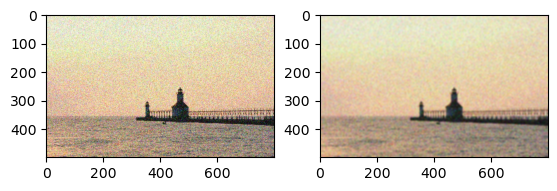

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_ruido= cv2.cvtColor( cv2.imread('./Img/ruido.jpg'), cv2.COLOR_BGR2RGB)
img_blur=cv2.GaussianBlur(img_ruido,(5,5),0)
kernel25x25 = np.ones((7,7),np.float32)/(7*7) #mas suavizado
suavizado3 = cv2.filter2D(img_blur,-1,kernel25x25) #imagen suavizada



plt.figure(figsize=(10,5))

plt.subplot(131)
plt.imshow(img_ruido,cmap='gray')

plt.subplot(132)
plt.imshow(suavizado3,cmap='gray')
plt.show()

Ejercicio 2

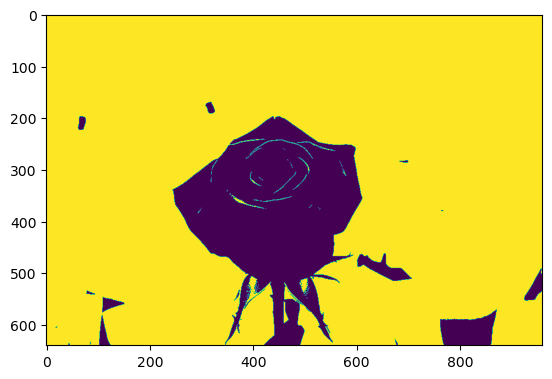

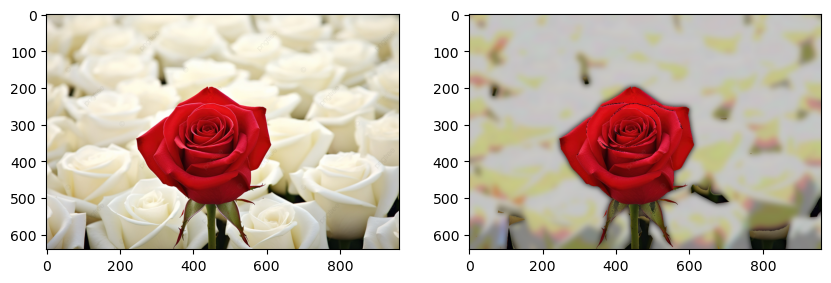

In [4]:
def conteo(img):
    img_gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    _,binaria=cv2.threshold(img_gray,100,202,cv2.THRESH_BINARY)
    return binaria
    

def desenfoqueROI(img):
  imgCopy = np.copy(img)
  binaria = conteo(img)
  plt.imshow(binaria)

  mask = cv2.cvtColor(binaria, cv2.COLOR_GRAY2BGR)
  img_mask = cv2.bitwise_and(img,mask)
  desenfoque = cv2.GaussianBlur(img_mask,(49,49),0)
  imgCopy[mask!=0] = desenfoque[mask!=0]
  return imgCopy

img_rosa = cv2.imread('./Img/rosa.png')

img_rgb = cv2.cvtColor(img_rosa, cv2.COLOR_BGR2RGB)
img_des = desenfoqueROI(img_rgb)
plt.figure(figsize=(10,5))
plt.subplot(121)
plt.imshow(img_rgb)
# plt.axis('off')
plt.subplot(122)
plt.imshow(img_des)

Ejercicio 3

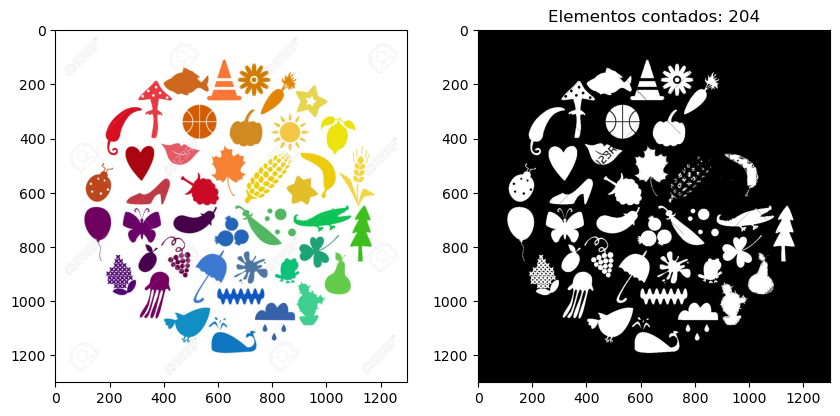

In [125]:
from skimage import measure


def conuntAmarillo (img):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  mask = cv2.inRange(img, (0, 180, 230), (20, 205, 255)  )
  img_gray = cv2.bitwise_not(img_gray, img_gray, mask=mask)
  _,binarizada = cv2.threshold(img_gray, 160,255,cv2.THRESH_BINARY_INV)
  mask = cv2.cvtColor(binarizada, cv2.COLOR_GRAY2BGR)
  contorno = measure.label(binarizada, connectivity=2)
  cont = np.max(contorno)
  return cont, binarizada    
imagen=cv2.imread('./Img/elementos.jpg')
img_cont,bin=conuntAmarillo(imagen)

plt.figure(figsize=(10,5))

plt.subplot(121)
plt.imshow(cv2.cvtColor(imagen,cv2.COLOR_BGR2RGB))

plt.subplot(122)
plt.title(f'Elementos contados: {img_cont -1}')
plt.imshow(bin,cmap='gray')
plt.show()

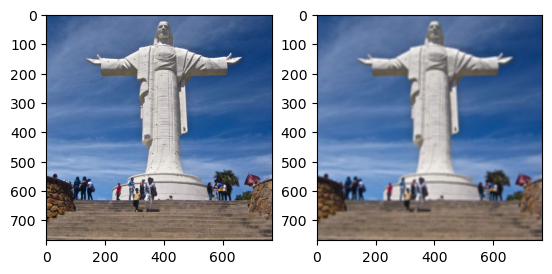

In [231]:
img_cristo= cv2.cvtColor( cv2.imread('./Img/cristo.jpg'), cv2.COLOR_BGR2RGB)

kernel = np.ones((5,5),np.float32)/(5*5)
suavizado = cv2.filter2D(img_cristo,-1,kernel25x25)
img_blur = cv2.GaussianBlur(img_cristo,(5,5),0)
img_blur = cv2.addWeighted(suavizado, 1.5, img_blur, -0.5, 0)


plt.subplot(121)
plt.imshow(img_cristo,cmap='gray')

plt.subplot(122)
plt.imshow(img_blur,cmap='gray')
plt.show()

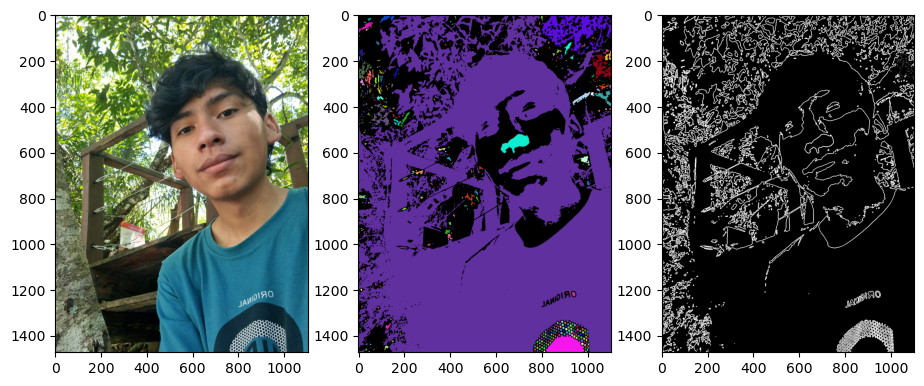

In [30]:
def roberts_mejorado(img):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

  suavizado = cv2.GaussianBlur(img_gray,(3,3),0)
  kernelx = np.array([[-2,0],[0,2]], dtype=np.float32)
  kernely = np.array([[0,2],[-2,0]], dtype=np.float32)

  robx = cv2.filter2D(suavizado, cv2.CV_16S,kernelx)
  roby = cv2.filter2D(suavizado, cv2.CV_16S,kernely)

  roberts = cv2.addWeighted(np.abs(robx), 0.7, np.abs(roby),0.7,0)

  _,border = cv2.threshold(roberts, 30, 355, cv2.THRESH_BINARY)
  return border



img = cv2.imread('./Img/Sergio.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

img_blur = cv2.GaussianBlur(img_gray,(5,5),0)



_,binarizado=cv2.threshold(img_blur,0,255,cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
#regiones

cant,region=cv2.connectedComponents(binarizado)
colores=np.random.randint(0,255,size=(cant,3),dtype=np.uint8)
colores[0]=[0,0,0]
color_reg=colores[region]

img_rob = roberts_mejorado(color_reg)

    

plt.figure(figsize=(15,10))
plt.subplot(141)
plt.imshow(img_rgb)
plt.subplot(142)
plt.imshow(color_reg, cmap='gray')
plt.subplot(143)
plt.imshow(img_rob, cmap='gray')

Primero hago una detecion de regiones para hacer la imagen plana y despues uso la deteccion de bordes de roberts mejorado para marcar los contornos de la figura

Ejercicio 6

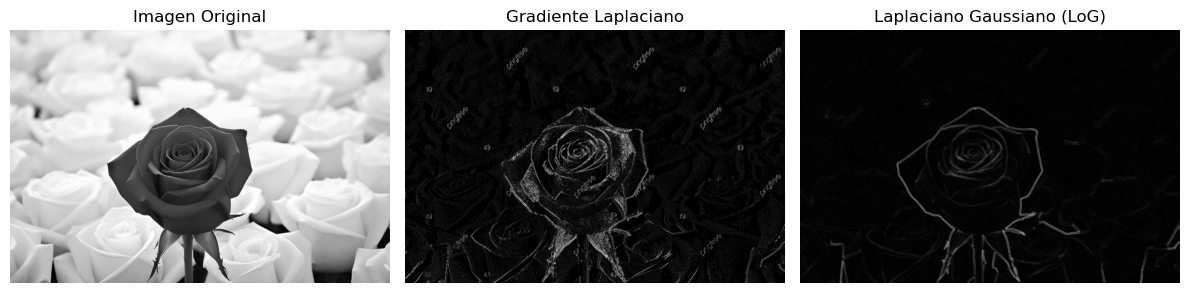

In [188]:
image = cv2.imread('./Img/rosa.png', cv2.IMREAD_GRAYSCALE)
gaussian_blur = cv2.GaussianBlur(image, (5, 5), 0)
mask3 = np.array([[0,0,0],[-1,1,0],[0,0,0]])*21 #kernel realce de bordes
image_rb = cv2.filter2D(image,-1,mask3)

laplacian = cv2.Laplacian(image_rb, cv2.CV_64F)
laplacian_of_gaussian = cv2.Laplacian(gaussian_blur, cv2.CV_64F)


# laplacian_of_gaussian = cv2.filter2D(laplacian_of_gaussian,-1,mask3)


plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.title("Imagen Original")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Gradiente Laplaciano")
plt.imshow(np.abs(laplacian), cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Laplaciano Gaussiano (LoG)")
plt.imshow(np.abs(laplacian_of_gaussian), cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()